In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from scipy.stats.mstats import winsorize
import warnings
print('imported em all')
warnings.filterwarnings('ignore')
print('ignored')
df=pd.read_csv('online_churn_clean(2nd).csv',parse_dates=['last_transaction'])
print('read_data')
df.sample(5)

imported em all
ignored
read_data


,customer_id,last_transaction,transactions,unique_products,revenue,total_days,days_inactive,frequency,aov,country,total_products,churn
2567,14900.0,2010-07-05 15:09:00,1,1,13.92,00:00:00,399 days 21:41:00,00:00:00,13.920000,United Kingdom,48,1
3486,15819.0,2011-10-21 14:50:00,11,183,3911.28,582 days 03:42:00,-73 days -02:00:00,52 days 22:09:16.363636,355.570909,United Kingdom,2913,0
1891,14224.0,2011-08-21 13:24:00,9,189,1897.90,433 days 23:38:00,-12 days -00:34:00,48 days 05:17:33.333333,210.877778,United Kingdom,863,0
454,12787.0,2011-11-30 08:44:00,5,30,859.18,403 days 17:47:00,-112 days -19:54:00,80 days 17:57:24,171.836000,Netherlands,509,0
4144,16477.0,2011-10-07 09:44:00,11,177,4320.02,421 days 00:01:00,-58 days -20:54:00,38 days 06:32:49.090909,392.729091,United Kingdom,2632,0


In [2]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
customer_id,5955.0,15310.277078,12346.0,13821.5,15310.0,16798.5,18287.0,1718.742774
last_transaction,5955,2011-05-21 07:42:12.181360384,2009-12-01 09:55:00,2010-11-23 16:33:30,2011-09-05 09:48:00,2011-11-15 11:15:30,2011-12-09 12:50:00,NaN
transactions,5955.0,7.535852,1.0,2.0,4.0,8.0,510.0,15.954215
unique_products,5955.0,81.154156,1.0,18.0,44.0,102.0,2557.0,116.271083
revenue,5955.0,2795.683018,-25111.09,324.655,842.41,2177.565,598215.22,13958.72664
aov,5955.0,293.363192,-25111.09,150.697721,231.625,357.1305,11880.84,520.840033
total_products,5955.0,1718.57733,-1085.0,180.0,474.0,1336.5,365220.0,8554.055839
churn,5955.0,0.467506,0.0,0.0,0.0,1.0,1.0,0.498985


In [3]:
df['total_days']=pd.to_timedelta(df['total_days'],errors='coerce').dt.days
df['days_inactive']=pd.to_timedelta(df['days_inactive'],errors='coerce').dt.days
df['frequency']=pd.to_timedelta(df['frequency'],errors='coerce').dt.days


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5955 entries, 0 to 5954
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       5955 non-null   float64       
 1   last_transaction  5955 non-null   datetime64[ns]
 2   transactions      5955 non-null   int64         
 3   unique_products   5955 non-null   int64         
 4   revenue           5955 non-null   float64       
 5   total_days        5955 non-null   int64         
 6   days_inactive     2805 non-null   float64       
 7   frequency         5955 non-null   int64         
 8   aov               5955 non-null   float64       
 9   country           5955 non-null   object        
 10  total_products    5955 non-null   int64         
 11  churn             5955 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(6), object(1)
memory usage: 558.4+ KB


In [5]:
df['aov']=winsorize(df['aov'],limits=[0.01,0.01])
df['revenue']=winsorize(df['revenue'],limits=[0.01,0.01])
df['transactions']=winsorize(df['transactions'],limits=[0.01,0.01])
df['frequency']=winsorize(df['frequency'],limits=[0.01,0.01])

In [6]:
churn_count=df['churn'].value_counts()
total_customers=df['customer_id'].count()
churn_percentage=round((df['churn'].sum()/df['customer_id'].count())*100,2)
print(f'Total Customers;{total_customers}')
print(f'Churned; {churn_count}')
print(f'churned_percentage;{churn_percentage}%')
print('aloot of churn, thats sad')

Total Customers;5955
Churned; churn
0    3171
1    2784
Name: count, dtype: int64
churned_percentage;46.75%
aloot of churn, thats sad


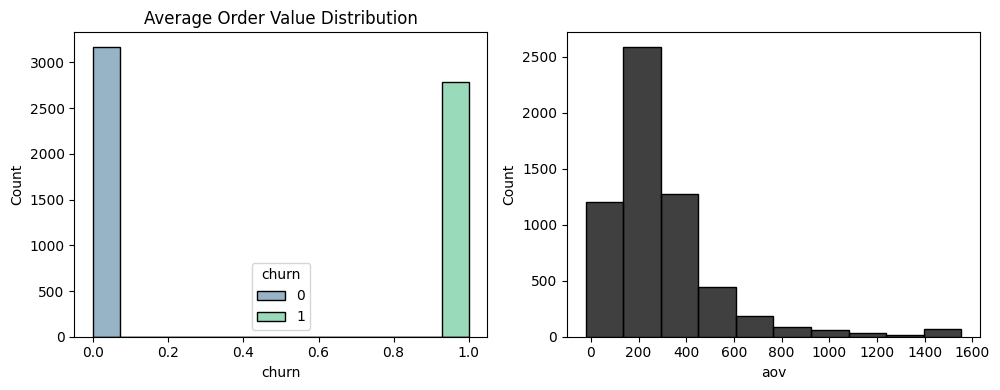

In [7]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.histplot(x='churn',data=df,hue='churn',palette='viridis',ax=ax[0])
ax[0].set(title='Churn Distribution')
sns.histplot(x='aov',bins=10,data=df,color='black',ax=ax[1])
ax[0].set(title='Average Order Value Distribution')
plt.tight_layout()

In [8]:
churned = df[df['churn'] == 1]
active = df[df['churn'] == 0]
comparison = pd.DataFrame({
    'Metric': ['Avg Revenue', 'Avg Transactions', 'Avg AOV', 'Avg Days Active', 'Avg Days Inactive'],
    'Churned': [
        churned['revenue'].mean(),
        churned['transactions'].mean(),
        churned['aov'].mean(),
        churned['total_days'].mean(),
        churned['days_inactive'].mean()
    ],
    'Active': [
        active['revenue'].mean(),
        active['transactions'].mean(),
        active['aov'].mean(),
        active['total_days'].mean(),
        active['days_inactive'].mean()
    ]
})

print(comparison.to_string(index=False))

           Metric    Churned      Active
      Avg Revenue 901.515808 3341.709849
 Avg Transactions   3.306034   10.110691
          Avg AOV 262.542362  318.235825
  Avg Days Active 135.424928  399.006307
Avg Days Inactive 268.697917  -52.904762


In [9]:
print(f'{churned['days_inactive'].mean()}')

268.6979166666667


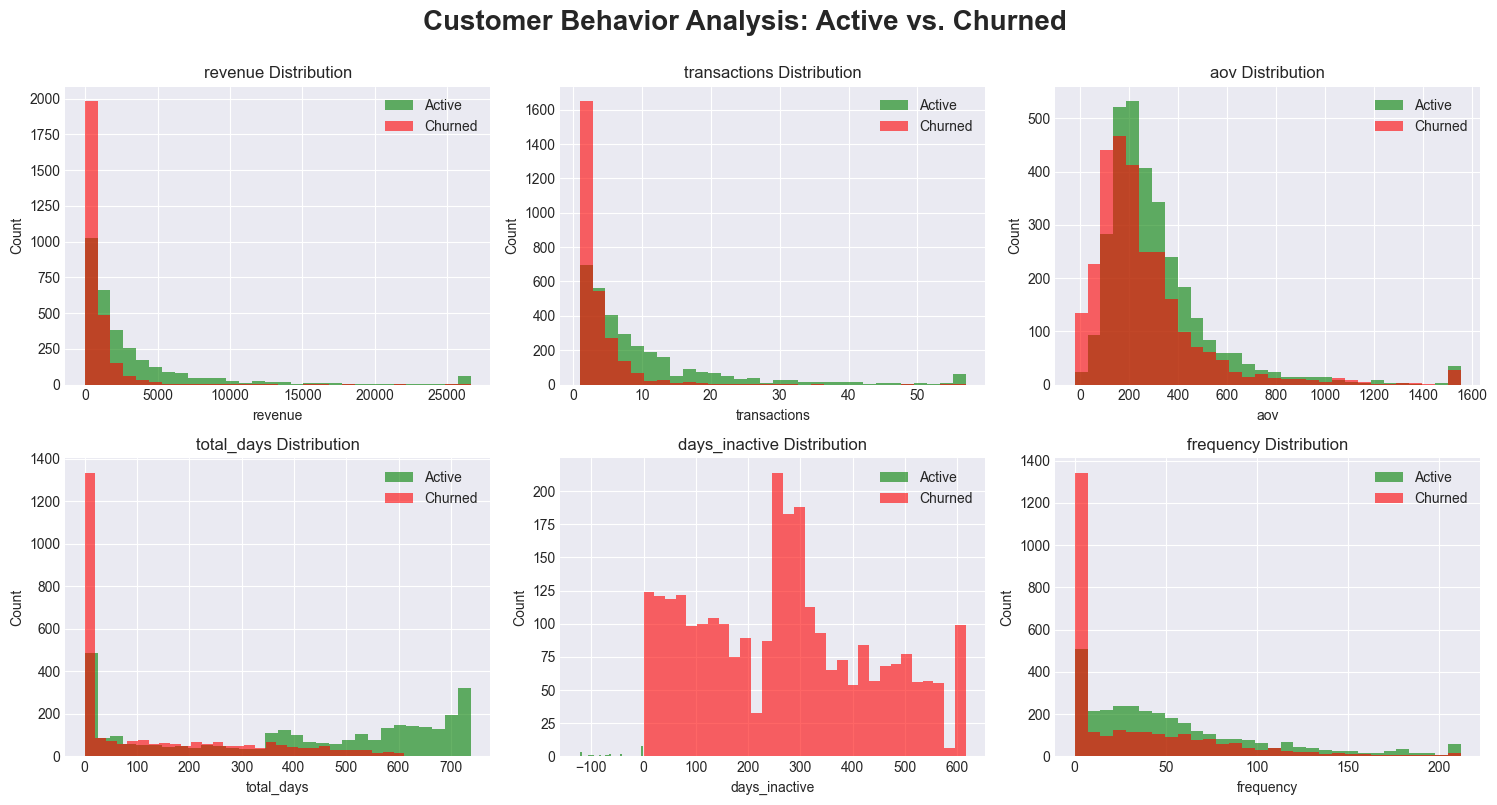

In [11]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['revenue', 'transactions', 'aov', 'total_days', 'days_inactive', 'frequency']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    active[feature].hist(alpha=0.6, label='Active', ax=ax, bins=30, color='green')
    churned[feature].hist(alpha=0.6, label='Churned', ax=ax, bins=30, color='red')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_title(f'{feature} Distribution')
fig.suptitle('Customer Behavior Analysis: Active vs. Churned', fontsize=20, fontweight='bold', y=1)
plt.tight_layout()
plt.savefig('Online_Retail_churn_eda.png',dpi=300)

In [12]:
df['rev_seg']=pd.qcut(df['revenue'],q=4,labels=['low','medium','high','premium'])
df['freq_seg']=pd.qcut(df['frequency'],q=3,labels=['None','regular','frequent'])
df['trans_seg']=pd.qcut(df['transactions'],q=4,labels=['Rare', 'Occasional', 'Regular', 'Frequent'])

In [13]:
rev_seg_churn=pd.crosstab(df['rev_seg'],df['churn'],margins=True,margins_name='Total')
rev_seg_churn['churn%']=((segment_churn[1]/(segment_churn[1]+segment_churn[0]))*100).round(2)
rev_seg_churn

NameError: name 'segment_churn' is not defined

In [14]:
top_countries=df['country'].value_counts().head(5).index
top_countries

Index(['United Kingdom', 'Germany', 'France', 'Spain', 'Belgium'], dtype='object', name='country')

In [15]:
country_churn=df[df['country'].isin(top_countries)].groupby('country')['churn'].agg(['sum','count'])
country_churn

,sum,count
country,,
Belgium,10,29
France,28,95
Germany,33,107
Spain,17,41
United Kingdom,2557,5410


In [16]:
country_churn['churn_rate']=(country_churn['sum']/country_churn['count']*100).round(2)

In [17]:
country_churn

,sum,count,churn_rate
country,,,
Belgium,10,29,34.48
France,28,95,29.47
Germany,33,107,30.84
Spain,17,41,41.46
United Kingdom,2557,5410,47.26


<Axes: xlabel='country', ylabel='sum'>

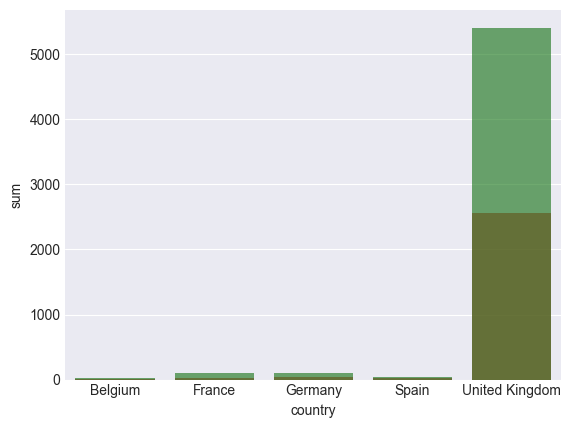

In [18]:
sns.barplot(x='country',y='sum',color='red',alpha=0.6,data=country_churn)
sns.barplot(x='country',y='count',color='green',alpha=0.6,data=country_churn)

In [19]:
trans_seg=pd.crosstab(df['trans_seg'],df['churn'],margins=True,margins_name='Total')
trans_seg['churn%']=(trans_seg[1]/(trans_seg[1]+trans_seg[0])*100).round(2)
trans_seg

churn,0,1,Total,churn%
trans_seg,,,,
Rare,694,1652,2346,70.42
Occasional,562,545,1107,49.23
Regular,694,409,1103,37.08
Frequent,1221,178,1399,12.72
Total,3171,2784,5955,46.75


Text(0.5, 1, 'Segment Analysis')

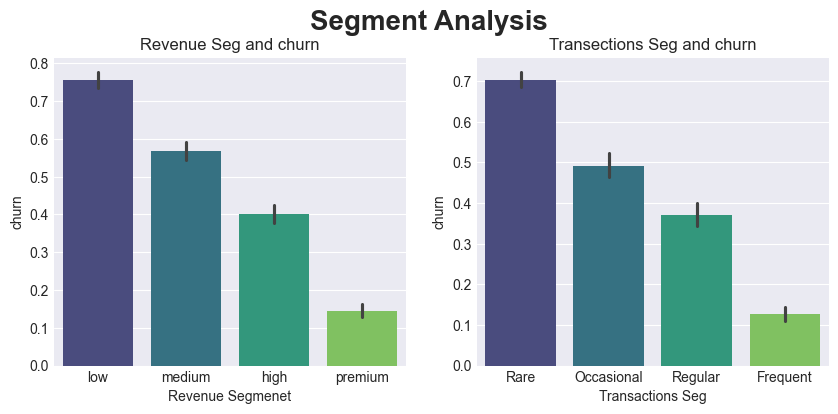

In [20]:
rev_graph=df.groupby('rev_seg')['churn'].mean()
trans_graph=df.groupby('trans_seg')['churn'].mean()
fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.barplot(x='rev_seg',y='churn',data=df,ax=ax[0],hue='rev_seg',palette='viridis')
ax[0].set_title('Revenue Seg and churn')
ax[0].set_xlabel('Revenue Segmenet')
sns.barplot(x='trans_seg',y='churn',data=df,ax=ax[1],hue='trans_seg',palette='viridis')
ax[1].set_title('Transections Seg and churn')
ax[1].set_xlabel('Transactions Seg')
plt.suptitle('Segment Analysis',fontsize=20,y=1,fontweight='bold')

In [21]:
df['churn']=pd.to_numeric(df['churn'],errors='coerce')
numeric_df=df.select_dtypes(include=[np.number])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5955 entries, 0 to 5954
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       5955 non-null   float64       
 1   last_transaction  5955 non-null   datetime64[ns]
 2   transactions      5955 non-null   int64         
 3   unique_products   5955 non-null   int64         
 4   revenue           5955 non-null   float64       
 5   total_days        5955 non-null   int64         
 6   days_inactive     2805 non-null   float64       
 7   frequency         5955 non-null   int64         
 8   aov               5955 non-null   float64       
 9   country           5955 non-null   object        
 10  total_products    5955 non-null   int64         
 11  churn             5955 non-null   int64         
 12  rev_seg           5955 non-null   category      
 13  freq_seg          5955 non-null   category      
 14  trans_seg         5955 n

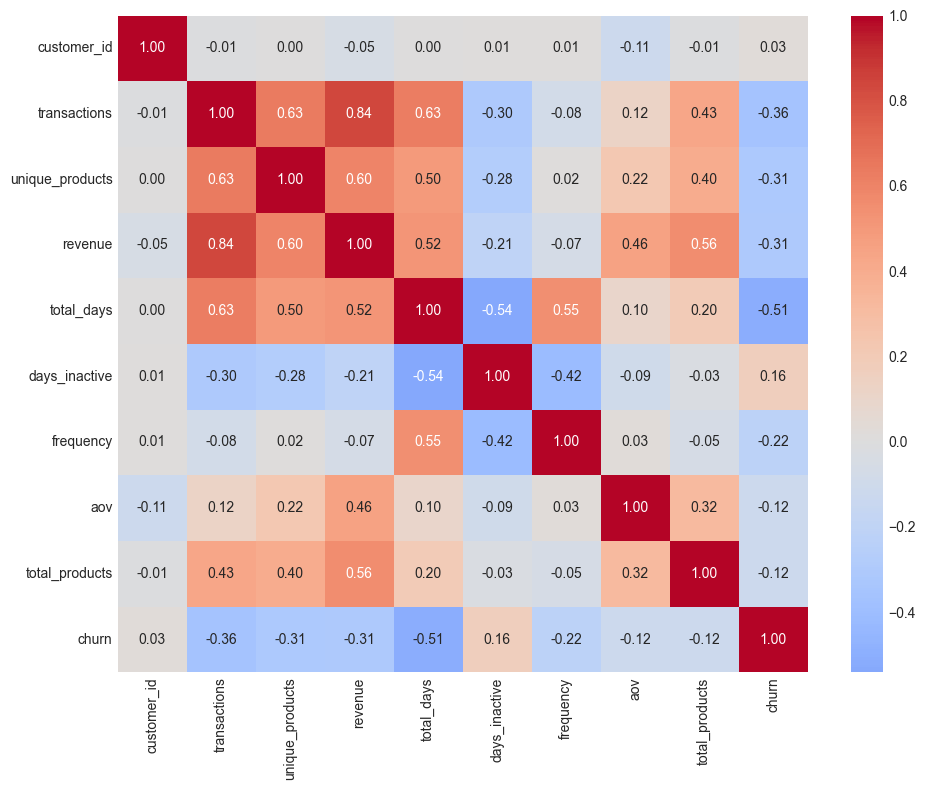

In [22]:
correlation=numeric_df.corr()['churn'].sort_values(ascending=False)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',center=0,fmt='.2f')
plt.tight_layout()
plt.savefig('heatmap_alot.png',dpi=300)

In [23]:
feature_columns = ['revenue', 'transactions', 'unique_products', 'aov', 'total_days', 'frequency', 'total_products']
df_model=df[feature_columns+['churn']].dropna()
x=df_model[feature_columns]
y=df_model['churn']
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5955 entries, 0 to 5954
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   revenue          5955 non-null   float64
 1   transactions     5955 non-null   int64  
 2   unique_products  5955 non-null   int64  
 3   aov              5955 non-null   float64
 4   total_days       5955 non-null   int64  
 5   frequency        5955 non-null   int64  
 6   total_products   5955 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 325.8 KB


In [24]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[-0.56012165,  1.06626211, -0.43999291, ...,  0.47835867,
        -0.43304214, -0.19484527],
       [ 0.86223451,  0.11334702,  0.38573314, ...,  0.48606049,
         0.12088703,  0.18325275],
       [-0.04559436, -0.20429134, -0.48299947, ...,  0.33202409,
         0.57223672,  0.11637827],
       ...,
       [-0.4456106 , -0.62780916, -0.59481654, ..., -1.06200529,
        -0.90490773, -0.18397232],
       [-0.25433682, -0.41605025, -0.12174433, ..., -0.11083055,
         0.77739567, -0.13171202],
       [ 0.4966256 ,  0.11334702,  0.34272657, ...,  1.6143771 ,
         0.85945925,  0.15110156]], shape=(5955, 7))

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [26]:
model=LogisticRegression(random_state=42,max_iter=2000)
model.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [27]:
y_pred_test=model.predict(x_test)
y_prob_test=model.predict_proba(x_test)[:,1]

In [28]:
print(f'{classification_report(y_test,y_pred_test)}')

              precision    recall  f1-score   support

           0       0.75      0.69      0.72       634
           1       0.68      0.74      0.71       557

    accuracy                           0.71      1191
   macro avg       0.71      0.72      0.71      1191
weighted avg       0.72      0.71      0.71      1191



In [29]:
print(f'{confusion_matrix(y_test,y_pred_test)}')

[[439 195]
 [146 411]]


In [30]:
all_probs = model.predict_proba(x_scaled)[:, 1]


In [31]:
df_risk_scores = pd.DataFrame({
    'customer_id': df.loc[x.index, 'customer_id'],
    'churn_probability': all_probs
})

df_risk_scores

,customer_id,churn_probability
0,12346.0,0.347657
1,12347.0,0.210783
2,12348.0,0.396328
3,12349.0,0.078424
4,12350.0,0.735838
...,...,...
5950,18283.0,0.044699
5951,18284.0,0.737748
5952,18285.0,0.729499
5953,18286.0,0.500280


In [32]:

df_risk_scores.to_csv('customer_risk_scores.csv', index=False)

In [34]:

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)



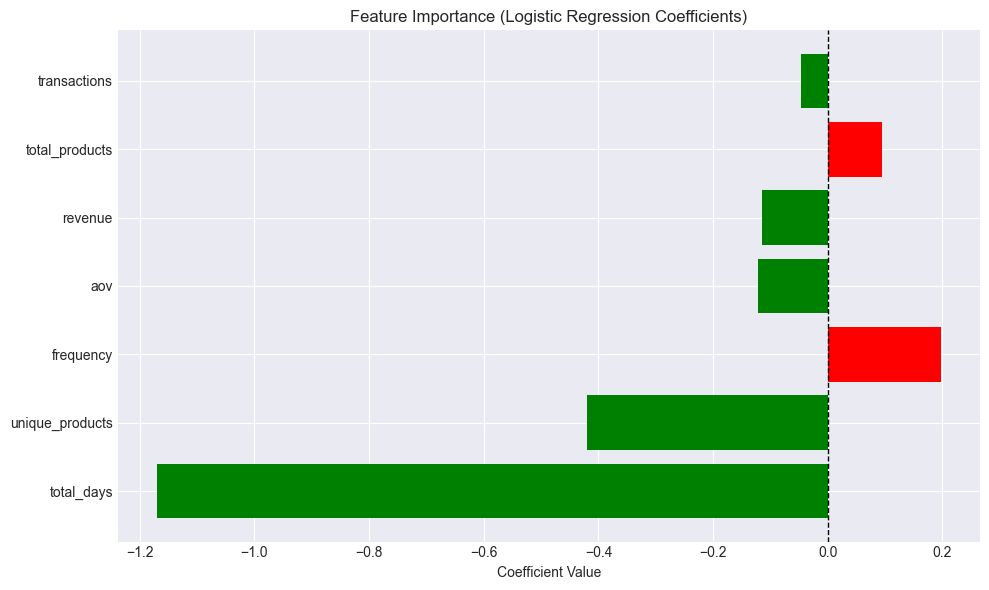

In [36]:
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('logistic_regression_feature_importance.png',dpi=300)